In [1]:
%load_ext autoreload
%autoreload 2

import util as yu
from util import *
import util_moments as yum
import util_charge as yuc

projs=['P0', 'Px', 'Py', 'Pz']
inserts=['tt', 'tx', 'ty', 'tz', 'xx', 'xy', 'xz', 'yy', 'yz', 'zz']
enss=['b','c','d','e']

In [31]:
path=f'/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DV/cD211.054.96/data_merge/disc_0,0,1,0,0,0.h5'
js=['j+;disc','jg;stout10']
key2tf2c3pt={j:{} for j in js}
with h5py.File(path) as f:
    moms3=[list(m) for m in f['moms'][:]]
    for jtf in f['data'].keys():
        j,tf=jtf.split('_'); tf=int(tf)
        if j not in js or tf>10:
            continue
        t=f[f'data/{jtf}'][:]
        key2tf2c3pt[j][tf]=yu.jackknife(t)
        
path=f'/p/project1/ngff/li47/code/projectData/05_moments/cD211.054.96/data_merge/disc_2pt.h5'
with h5py.File(path) as f:
    moms=yu.moms2list(f['moms'][:])
    c2pt=f['data/N_N'][:,:,moms.index([0,0,1])]
    c2pt_symmetrized=yu.jackknife(np.real(c2pt))

In [3]:
ens='d'

path=f'/p/project1/ngff/li47/code/projectData/05_moments/cD211.054.96/data_merge/disc_2pt_vevsub.h5'
with h5py.File(path) as f:
    moms=[list(m) for m in f['moms'][:]]
    td='data'
    t=(f[f'{td}/N1_N1'][:]+f[f'{td}/N2_N2'][:])/2
    c2pt_fw=yu.jackknife(t)
    td='data_bw'
    t=(f[f'{td}/N1_N1'][:]+f[f'{td}/N2_N2'][:])/2
    c2pt_bw=yu.jackknife(t)

In [33]:
key2vev={}
for ens in ['d']:
    path=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/disc_jvev.h5'
    with h5py.File(path) as f:
        for j in js:
            t=f[j][:]
            key2vev[(ens,j)]=yu.jackknife(t)

(493, 11) (493, 1) (493, 1)
[340(110), 440(110), 550(110), 640(110), 630(120), 560(110), 570(110), 640(110), 600(110), 410(110), 210(110)]
[3.9(5.2)]
       1   0.8148   0.4628    0.192  0.05848 -0.005969 -0.03305 -0.01962  0.01887  0.07174   0.1153
  0.8148        1   0.8368    0.491    0.199  0.03389 -0.03035 -0.007648  0.03148  0.06708   0.1019
  0.4628   0.8368        1   0.8248   0.4673   0.1781  0.02467  0.01422  0.04097  0.06014  0.07887
   0.192    0.491   0.8248        1   0.8338   0.4893   0.1858  0.07187  0.05369  0.05363  0.05886
 0.05848    0.199   0.4673   0.8338        1   0.8329   0.4697   0.2091  0.08324  0.04148  0.03596
-0.005969  0.03389   0.1781   0.4893   0.8329        1   0.8237   0.4813   0.1939  0.06486  0.04381
-0.03305 -0.03035  0.02467   0.1858   0.4697   0.8237        1   0.8326   0.4799    0.217   0.1224
-0.01962 -0.007648  0.01422  0.07187   0.2091   0.4813   0.8326        1   0.8321   0.4982    0.263
 0.01887  0.03148  0.04097  0.05369  0.08324   0.1939 

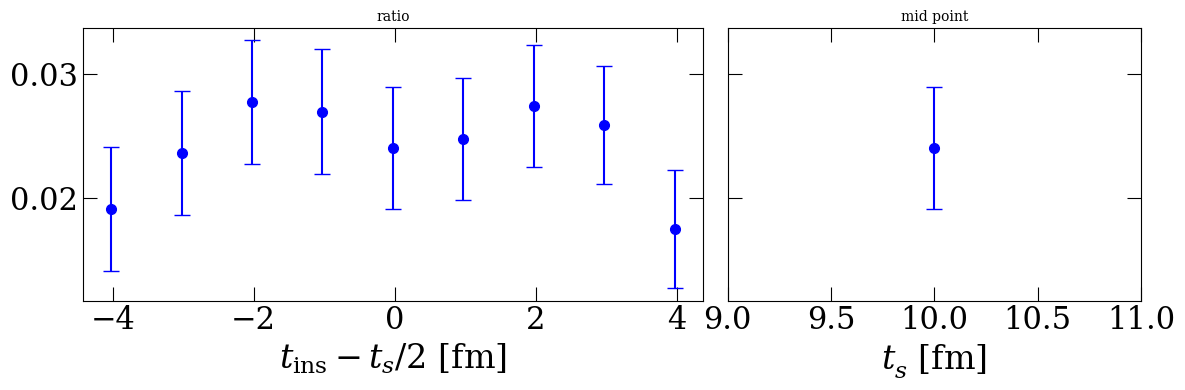

In [34]:
j='j+;disc'
j='jg;stout10'
tf2c3pt=key2tf2c3pt[j]
tf2ratio={}
for tf in tf2c3pt.keys():
    if tf!=10:
        continue
    c3pt=tf2c3pt[tf][:,:,moms3.index([0,0,1,0,0,0]),projs.index('P0'),inserts.index('tz')]
    c2pt=c2pt_fw[:,tf:tf+1,moms.index([0,0,1]),projs.index('P0')]
    vev= key2vev[(ens,j)][:,inserts.index('tz')][:,None]
    
    print(c3pt.shape,c2pt.shape,vev.shape)
    print(yu.jackme_un2str(np.imag(c3pt)*1e15))
    print(yu.jackme_un2str(np.imag(c2pt)*np.real(vev)*1e15))
    c3pt = c3pt - c2pt*vev

    ratio=c3pt/c2pt_symmetrized[:,tf:tf+1]
    
    m,e,c=yu.jackmec(np.imag(ratio))
    print(yu.formatMatrix(yu.cov2correlation(c)))
    
    tf2ratio[tf]=np.imag(ratio)
    
yu.makePlot_3pt_rainbow(tf2ratio,tfmax=10)
yu.finalizePlot()

In [6]:
# enss=['d']
# ens='d'

# ens2c2pt={}; ens2moms_2pt={}; ens2c2pt0={}; ens2Njk={}
# ens2c2pt_complex={}
# for ens in enss:
#     basepath=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/'
#     path=f'{basepath}disc_2pt.h5'
#     with h5py.File(path) as f:
#         moms_2pt=yu.moms2list(f['moms'])
#         c2pt=yu.jackknife(np.real(f['data/N_N'][:,:,:]))
#         c2pt_complex=yu.jackknife(f['data/N_N'][:,:,:])
        
#     ens2moms_2pt[ens]=moms_2pt
#     ens2c2pt[ens]=c2pt
#     ens2c2pt0[ens]=c2pt[:,:,moms_2pt.index([0,0,0])]
#     ens2c2pt_complex[ens]=c2pt_complex
#     ens2Njk[ens]=len(c2pt)

# projs=['P0', 'Px', 'Py', 'Pz']
# inserts=['tt', 'tx', 'ty', 'tz', 'xx', 'xy', 'xz', 'yy', 'yz', 'zz']

# stouts=[10]
# # stouts=range(0,41)
# js=['j+;disc','js;disc','jc;disc']+[f'jg;stout{stout}' for stout in stouts]

# key2vev={}
# for ens in enss:
#     path=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/disc_jvev.h5'
#     with h5py.File(path) as f:
#         for j in js:
#             t=f[j][:]
#             key2vev[(ens,j)]=yu.jackknife(t)

# key2tf2ratio={}
# key2tf2ratio_vevsub={}
# for ens in enss:
#     path=f'/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DV/{yu.ens2full[ens]}/data_merge/disc_0,0,1,0,0,0.h5'
#     with h5py.File(path) as f:
#         for jtf in f['data'].keys():
#             j,tf=jtf.split('_'); tf=int(tf)
#             if j not in js:
#                 continue        
#             key=(ens,j)
#             if key not in key2tf2ratio:
#                 key2tf2ratio[key]={}
#                 key2tf2ratio_vevsub[key]={}
#             c3pt=yu.jackknife(f['data'][jtf][:,:,0,projs.index('P0'),inserts.index('tz')])
#             c2pt=ens2c2pt[ens][:,tf,ens2moms_2pt[ens].index([0,0,1])]
            
#             c2pt_complex=ens2c2pt_complex[ens][:,tf,ens2moms_2pt[ens].index([0,0,1])]
#             c3pt_vevsub=c3pt - ( c2pt_complex * key2vev[key][:,inserts.index('tz')] )[:,None]
            
#             print(jtf,np.mean(c3pt[:,tf//2]),np.mean(c3pt_vevsub[:,tf//2]))
#             print(np.mean(c2pt_complex),np.mean(key2vev[key][:,inserts.index('tz')] ) )

#             factor=1/(1j*2*np.pi/yu.ens2NL[ens])
#             ratio=np.real(c3pt/c2pt[:,None]*factor)
#             key2tf2ratio[key][tf]=ratio
#             ratio_vevsub=np.real(c3pt_vevsub/c2pt[:,None]*factor)
#             key2tf2ratio_vevsub[key][tf]=ratio_vevsub
            
# ens2tfs_disc={}
# for ens in enss:
#     tfs=list(key2tf2ratio[(ens,'j+;disc')].keys()); tfs.sort()
#     ens2tfs_disc[ens]=tfs
#     print(ens,tfs[0],tfs[-1])
    
# path='pkl/analysis_c2pt/reg_ignore/ens2pars_jk_meffnst_selected.pkl'
# [ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]=yu.load_pkl(path)
